In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import optimize, special

# ===================== User Settings =====================
# Use current working directory (script's folder) by default
folderpath = '.'                   # data files reside in the same folder as this script
sample     = '3B_P1'               # sample identifier prefix
QD         = 1                     # Quantum device flag
downswitch = -89.581               # known downsweep switch field
upswitch   = 141.434               # known upsweep switch field

# Sweep configuration: fraction around best-fit, and number of steps
sweep_fractions = {
    'k' : 0.2,     # ±20% around best-fit
    'm' : 0.2,
    'ic': 0.2
}
sweep_steps = 7  # number of values per sweep

# ===================== Load Data =====================
# Change working directory if needed
os.chdir(folderpath)
# Construct filenames
downsweep = f'{sample}_Downsweep_1100B'
upsweep   = f'{sample}_upsweep_1100B'
# Load data arrays
data_down = np.loadtxt(downsweep)
data_up   = np.loadtxt(upsweep)
H_down, Ic_down = data_down[:,0], data_down[:,2]
H_up,   Ic_up   = data_up[:,0],   data_up[:,2]

# ===================== Compute Rn and I_cR_n =====================
down_Ic_max = Ic_down.max()
up_Ic_max   = Ic_up.max()
if QD < 3:
    down_Rn = 5 * 9.461 * data_down[1,3] * 1.0006e-6
    up_Rn   = 5 * 9.461 * data_up[1,3]   * 1.0006e-6
else:
    down_Rn = data_down[1,3] * 1e3
    up_Rn   = data_up[1,3]   * 1e3

# ===================== Define Fit Function =====================
def airy_ic(H, k, m, ic):
    # Fraunhofer (Airy) pattern model
    arg = k * (H + m)
    # avoid division by zero for arg=0
    return 2 * ic * np.where(arg==0, 0, np.abs(special.jv(1, arg) / arg))

# ===================== Best-Fit via curve_fit =====================
# Select data segments based on switch fields
down_idx = H_down > downswitch
up_idx   = H_up   < upswitch

# initial guess for [k, m, ic]
p0 = [-0.03, 50, 0.01]
# Perform fits
best_downparams, _ = optimize.curve_fit(airy_ic, H_down[down_idx], Ic_down[down_idx], p0=p0)
best_upparams,   _ = optimize.curve_fit(airy_ic, H_up[up_idx],     Ic_up[up_idx],   p0=p0)

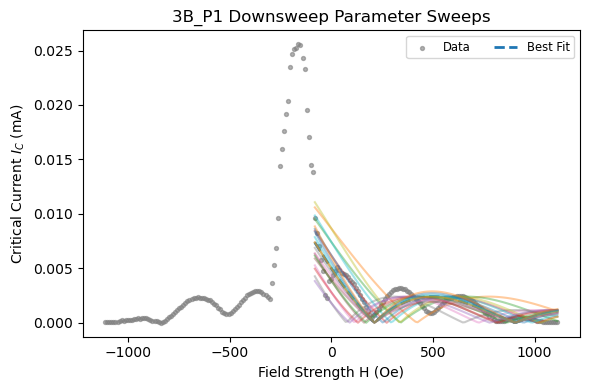

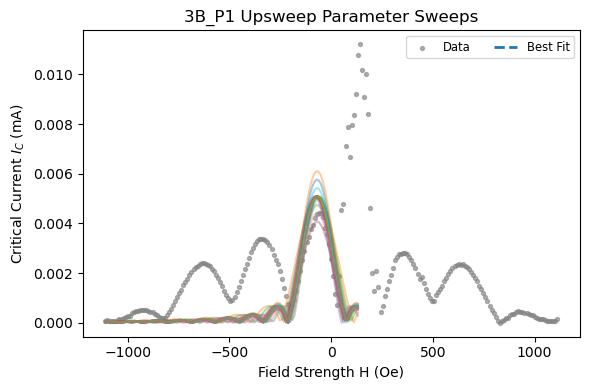

In [14]:
# ===================== Parameter Sweeps and Plotting =====================
for label, best_params in [('Downsweep', best_downparams), ('Upsweep', best_upparams)]:
    # Assign data for this sweep
    if label == 'Downsweep':
        H, Ic = H_down, Ic_down
        idx   = down_idx
    else:
        H, Ic = H_up, Ic_up
        idx   = up_idx

    k0, m0, ic0 = best_params

    # Initialize plot
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(H, Ic, s=8, color='gray', alpha=0.6, label='Data')
    ax.plot(H[idx], airy_ic(H[idx], *best_params), '--', lw=2, label='Best Fit')
    ax.set_title(f'{sample} {label} Parameter Sweeps')
    ax.set_xlabel('Field Strength H (Oe)')
    ax.set_ylabel('Critical Current $I_C$ (mA)')

    # Sweep k only
    k_vals = np.linspace(k0*(1-sweep_fractions['k']), k0*(1+sweep_fractions['k']), sweep_steps)
    for k in k_vals:
        ax.plot(H[idx], airy_ic(H[idx], k, m0, ic0), alpha=0.4)

    # Sweep m only
    m_vals = np.linspace(m0*(1-sweep_fractions['m']), m0*(1+sweep_fractions['m']), sweep_steps)
    for m in m_vals:
        ax.plot(H[idx], airy_ic(H[idx], k0, m, ic0), alpha=0.4)

    # Sweep ic only
    ic_vals = np.linspace(ic0*(1-sweep_fractions['ic']), ic0*(1+sweep_fractions['ic']), sweep_steps)
    for ic in ic_vals:
        ax.plot(H[idx], airy_ic(H[idx], k0, m0, ic), alpha=0.4)

    ax.legend(loc='upper right', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

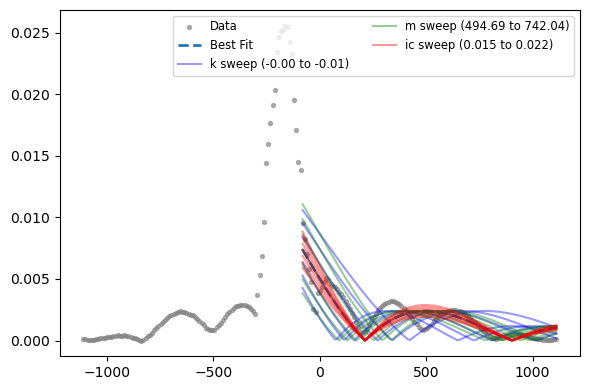

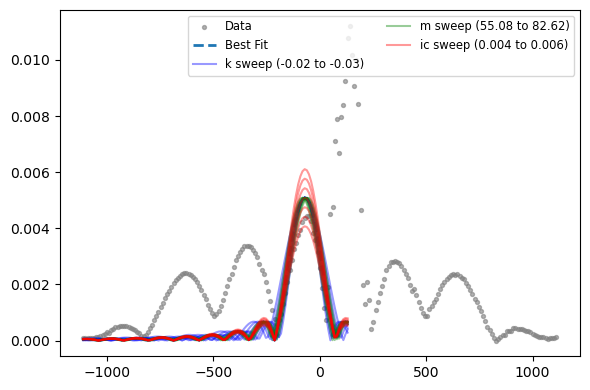

In [15]:
# ===================== Parameter Sweeps and Plotting =====================
for label, best_params in [('Downsweep', best_downparams), ('Upsweep', best_upparams)]:
    # Assign data for this sweep
    if label == 'Downsweep':
        H, Ic = H_down, Ic_down
        idx   = down_idx
    else:
        H, Ic = H_up, Ic_up
        idx   = up_idx

    k0, m0, ic0 = best_params

    # Initialize plot
    fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(H, Ic, s=8, color='gray', alpha=0.6, label='Data')
    ax.plot(H[idx], airy_ic(H[idx], *best_params), '--', lw=2, label='Best Fit')
    
    # Define colors and calculate ranges for each parameter
    param_colors = {
        'k': ('blue', k0, sweep_fractions['k']),
        'm': ('green', m0, sweep_fractions['m']),
        'ic': ('red', ic0, sweep_fractions['ic'])
    }

    # Sweep k only with labels
    k_min = k0 * (1 - sweep_fractions['k'])
    k_max = k0 * (1 + sweep_fractions['k'])
    k_vals = np.linspace(k_min, k_max, sweep_steps)
    for i, k in enumerate(k_vals):
        ax.plot(H[idx], airy_ic(H[idx], k, m0, ic0), 
                color='blue', 
                alpha=0.4,
                label='k sweep ({:.2f} to {:.2f})'.format(k_min, k_max) if i == 0 else None)

    # Sweep m only with labels
    m_min = m0 * (1 - sweep_fractions['m'])
    m_max = m0 * (1 + sweep_fractions['m'])
    m_vals = np.linspace(m_min, m_max, sweep_steps)
    for i, m in enumerate(m_vals):
        ax.plot(H[idx], airy_ic(H[idx], k0, m, ic0), 
                color='green', 
                alpha=0.4,
                label='m sweep ({:.2f} to {:.2f})'.format(m_min, m_max) if i == 0 else None)

    # Sweep ic only with labels
    ic_min = ic0 * (1 - sweep_fractions['ic'])
    ic_max = ic0 * (1 + sweep_fractions['ic'])
    ic_vals = np.linspace(ic_min, ic_max, sweep_steps)
    for i, ic in enumerate(ic_vals):
        ax.plot(H[idx], airy_ic(H[idx], k0, m0, ic), 
                color='red', 
                alpha=0.4,
                label='ic sweep ({:.3f} to {:.3f})'.format(ic_min, ic_max) if i == 0 else None)

    ax.legend(loc='upper right', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

In [7]:
# Sweep k only
k_vals = np.linspace(k0*(1-sweep_fractions['k']),
                         k0*(1+sweep_fractions['k']),
                         sweep_steps)
for i, k in enumerate(k_vals):
        lbl = f'k={k:.3g}' if i in (0, len(k_vals)-1) else None
        ax.plot(H[idx],
                airy_ic(H[idx], k, m0, ic0),
                alpha=0.4,
                color='C1',
                label=lbl)

    # Sweep m only
m_vals = np.linspace(m0*(1-sweep_fractions['m']),
                         m0*(1+sweep_fractions['m']),
                         sweep_steps)
for i, m in enumerate(m_vals):
        lbl = f'm={m:.2f}' if i in (0, len(m_vals)-1) else None
        ax.plot(H[idx],
                airy_ic(H[idx], k0, m, ic0),
                alpha=0.4,
                color='C2',
                label=lbl)

    # Sweep ic only
ic_vals = np.linspace(ic0*(1-sweep_fractions['ic']),
                          ic0*(1+sweep_fractions['ic']),
                          sweep_steps)
for i, ic in enumerate(ic_vals):
        lbl = f'Ic={ic:.3g}' if i in (0, len(ic_vals)-1) else None
        ax.plot(H[idx],
                airy_ic(H[idx], k0, m0, ic),
                alpha=0.4,
                color='C3',
                label=lbl)


In [8]:
    # Sweep k only with multiple labels
    k_vals = np.linspace(k0*(1-sweep_fractions['k']), 
                        k0*(1+sweep_fractions['k']), 
                        sweep_steps)
    for i, k in enumerate(k_vals):
        # Label first, middle, and last points
        lbl = f'k = {k:.3f}' if i in [0, sweep_steps//2, sweep_steps-1] else None
        ax.plot(H[idx], 
                airy_ic(H[idx], k, m0, ic0),
                alpha=0.4,
                color='C1',  # Orange color for k
                label=lbl)

    # Sweep m only with multiple labels
    m_vals = np.linspace(m0*(1-sweep_fractions['m']), 
                        m0*(1+sweep_fractions['m']), 
                        sweep_steps)
    for i, m in enumerate(m_vals):
        lbl = f'm = {m:.1f}' if i in [0, sweep_steps//2, sweep_steps-1] else None
        ax.plot(H[idx], 
                airy_ic(H[idx], k0, m, ic0),
                alpha=0.4,
                color='C2',  # Green color for m
                label=lbl)

    # Sweep ic only with multiple labels
    ic_vals = np.linspace(ic0*(1-sweep_fractions['ic']), 
                         ic0*(1+sweep_fractions['ic']), 
                         sweep_steps)
    for i, ic in enumerate(ic_vals):
        lbl = f'Ic = {ic:.3f}' if i in [0, sweep_steps//2, sweep_steps-1] else None
        ax.plot(H[idx], 
                airy_ic(H[idx], k0, m0, ic),
                alpha=0.4,
                color='C3',  # Red color for Ic
                label=lbl)

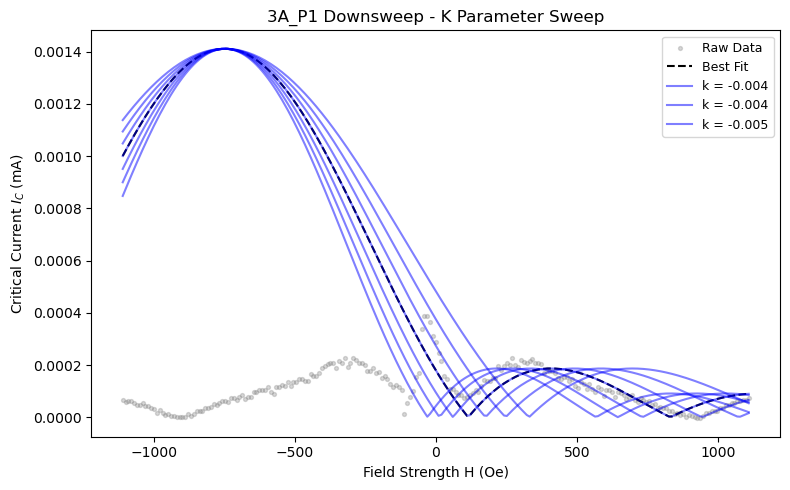

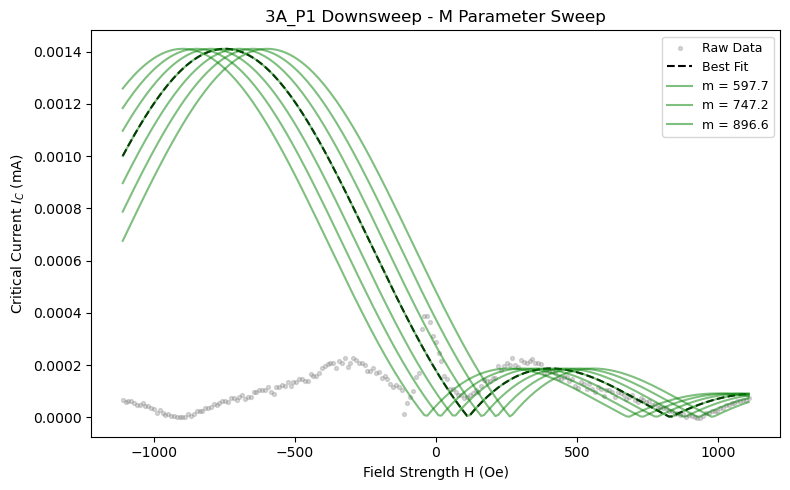

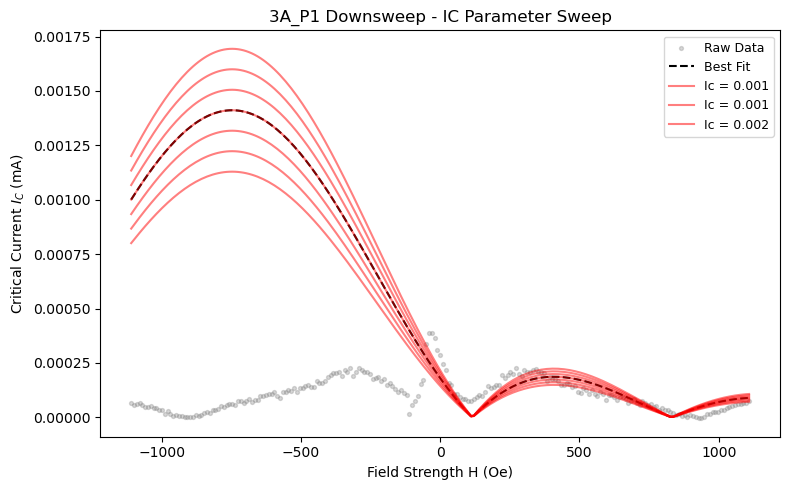

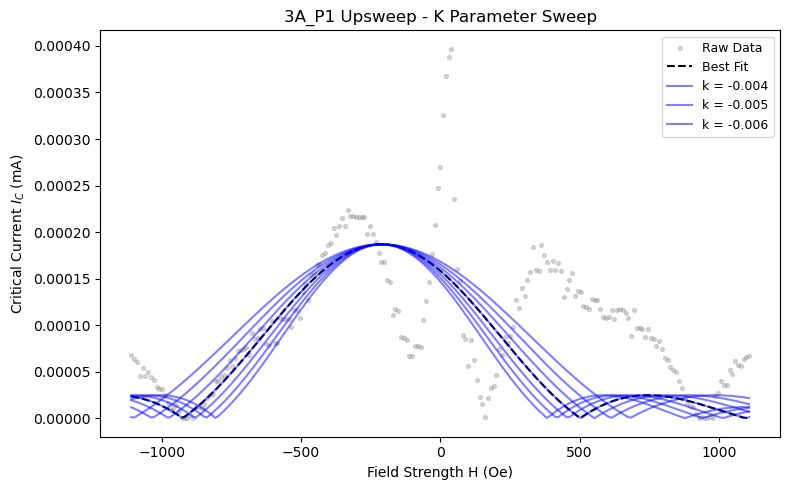

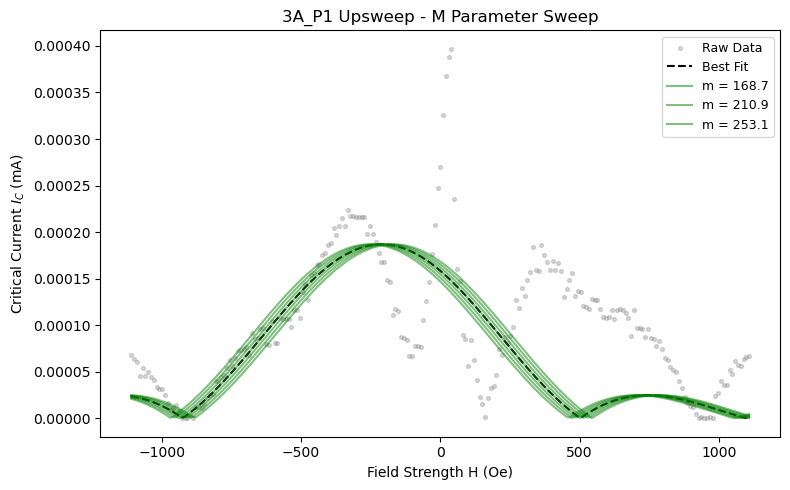

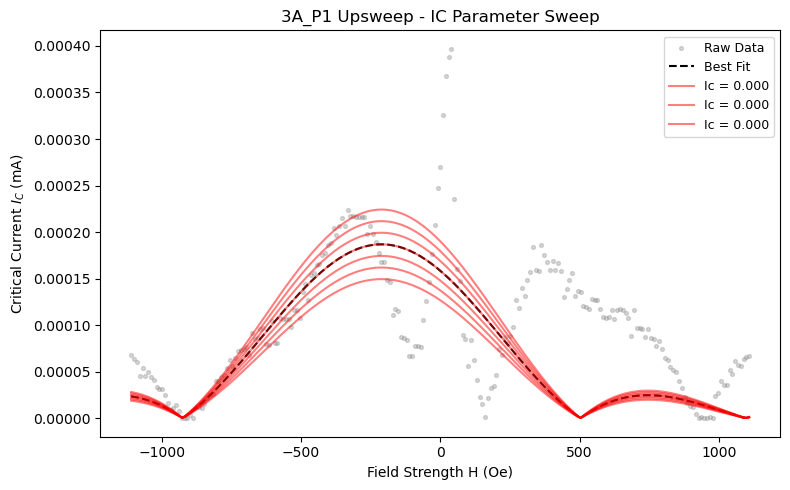

In [3]:
# ===================== Parameter Sweeps and Plotting =====================
for label, best_params, data in [('Downsweep', best_downparams, (H_down, Ic_down)), 
                                ('Upsweep', best_upparams, (H_up, Ic_up))]:
    H, Ic = data
    k0, m0, ic0 = best_params
    
    # Create 3 separate plots per sweep direction
    for param, color in [('k', 'blue'), ('m', 'green'), ('ic', 'red')]:
        fig, ax = plt.subplots(figsize=(8,5))
        
        # Plot full dataset and best fit
        ax.scatter(H, Ic, s=8, color='gray', alpha=0.3, label='Raw Data')
        ax.plot(H, airy_ic(H, *best_params), '--', color='black', lw=1.5, label='Best Fit')
        
        # Generate parameter values and plot sweeps
        if param == 'k':
            vals = np.linspace(k0*(1-sweep_fractions['k']), 
                             k0*(1+sweep_fractions['k']), 
                             sweep_steps)
            for i, val in enumerate(vals):
                lbl = f'k = {val:.3f}' if i in [0, len(vals)//2, len(vals)-1] else None
                ax.plot(H, airy_ic(H, val, m0, ic0), color=color, alpha=0.5, label=lbl)
        
        elif param == 'm':
            vals = np.linspace(m0*(1-sweep_fractions['m']), 
                             m0*(1+sweep_fractions['m']), 
                             sweep_steps)
            for i, val in enumerate(vals):
                lbl = f'm = {val:.1f}' if i in [0, len(vals)//2, len(vals)-1] else None
                ax.plot(H, airy_ic(H, k0, val, ic0), color=color, alpha=0.5, label=lbl)
        
        elif param == 'ic':
            vals = np.linspace(ic0*(1-sweep_fractions['ic']), 
                             ic0*(1+sweep_fractions['ic']), 
                             sweep_steps)
            for i, val in enumerate(vals):
                lbl = f'Ic = {val:.3f}' if i in [0, len(vals)//2, len(vals)-1] else None
                ax.plot(H, airy_ic(H, k0, m0, val), color=color, alpha=0.5, label=lbl)

        ax.set_title(f'{sample} {label} - {param.upper()} Parameter Sweep')
        ax.set_xlabel('Field Strength H (Oe)')
        ax.set_ylabel('Critical Current $I_C$ (mA)')
        ax.legend(loc='upper right', fontsize=9)
        plt.tight_layout()
        plt.show()

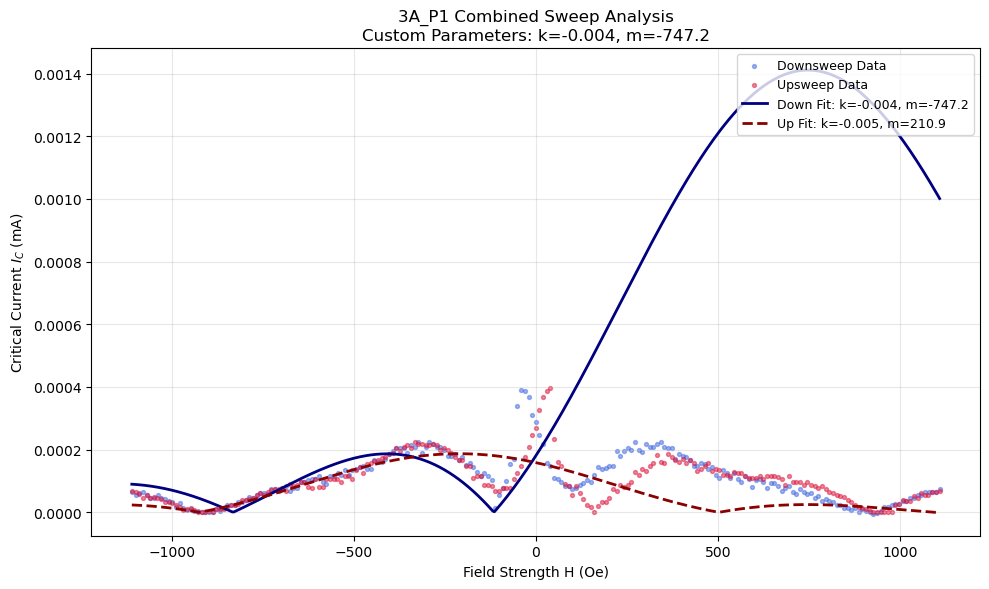

In [9]:
# ===================== Custom Fit Parameters =====================
custom_params = {
    'downsweep': {
        'k': -0.004444,
        'm': -747.151014,
        'ic': 0.001411  # Add your Ic value for downsweep here
    },
    'upsweep': {
        'k': -0.005368,
        'm': 210.931084,  # Modify if different for upsweep
        'ic': 0.000187    # Add your Ic value for upsweep here
    }
}

# ===================== Merged Plot =====================
plt.figure(figsize=(10, 6))

# Plot raw data with different colors
plt.scatter(H_down, Ic_down, s=8, color='royalblue', 
           alpha=0.5, label='Downsweep Data')
plt.scatter(H_up, Ic_up, s=8, color='crimson', 
           alpha=0.5, label='Upsweep Data')

# Plot fits using custom parameters
H_combined = np.linspace(min(H_down.min(), H_up.min()),
                        max(H_down.max(), H_up.max()),
                        500)

# Down sweep fit curve
fit_down = airy_ic(H_combined,
                  custom_params['downsweep']['k'],
                  custom_params['downsweep']['m'],
                  custom_params['downsweep']['ic'])
plt.plot(H_combined, fit_down, 'navy', lw=2, 
        label=f'Down Fit: k={custom_params["downsweep"]["k"]:.3f}, '
             f'm={custom_params["downsweep"]["m"]:.1f}')

# Up sweep fit curve
fit_up = airy_ic(H_combined,
                custom_params['upsweep']['k'],
                custom_params['upsweep']['m'],
                custom_params['upsweep']['ic'])
plt.plot(H_combined, fit_up, 'darkred', lw=2, linestyle='--',
        label=f'Up Fit: k={custom_params["upsweep"]["k"]:.3f}, '
             f'm={custom_params["upsweep"]["m"]:.1f}')

# Formatting
plt.title(f'{sample} Combined Sweep Analysis\n'
         f'Custom Parameters: k={custom_params["downsweep"]["k"]:.3f}, '
         f'm={custom_params["downsweep"]["m"]:.1f}')
plt.xlabel('Field Strength H (Oe)')
plt.ylabel('Critical Current $I_C$ (mA)')
plt.grid(alpha=0.3)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
# ===================== Best-Fit via curve_fit =====================
# Select data segments based on switch fields
down_idx = H_down > downswitch
up_idx   = H_up   < upswitch

# initial guess for [k, m, ic]
p0 = [-0.004444, 50, 0.01]
# Perform fits
best_downparams, _ = optimize.curve_fit(airy_ic, H_down[down_idx], Ic_down[down_idx], p0=p0)
best_upparams,   _ = optimize.curve_fit(airy_ic, H_up[up_idx],     Ic_up[up_idx],   p0=p0)

# Print the best-fit parameters for both sweeps
print("Best-fit parameters for Downsweep:")
print(f"k: {best_downparams[0]:.6f}, m: {best_downparams[1]:.6f}, ic: {best_downparams[2]:.6f}")
print("\nBest-fit parameters for Upsweep:")
print(f"k: {best_upparams[0]:.6f}, m: {best_upparams[1]:.6f}, ic: {best_upparams[2]:.6f}")

# ===================== Paste printed values here =====================
custom_params = {
    'downsweep': {
        'k': best_downparams[0],  # Replace with printed downsweep k value
        'm': best_downparams[1],  # Replace with printed downsweep m value
        'ic': best_downparams[2]  # Replace with printed downsweep ic value
    },
    'upsweep': {
        'k': best_upparams[0],    # Replace with printed upsweep k value
        'm': best_upparams[1],    # Replace with printed upsweep m value
        'ic': best_upparams[2]    # Replace with printed upsweep ic value
    }
}

Best-fit parameters for Downsweep:
k: -0.004444, m: 747.151014, ic: 0.001411

Best-fit parameters for Upsweep:
k: -0.005368, m: 210.931084, ic: 0.000187


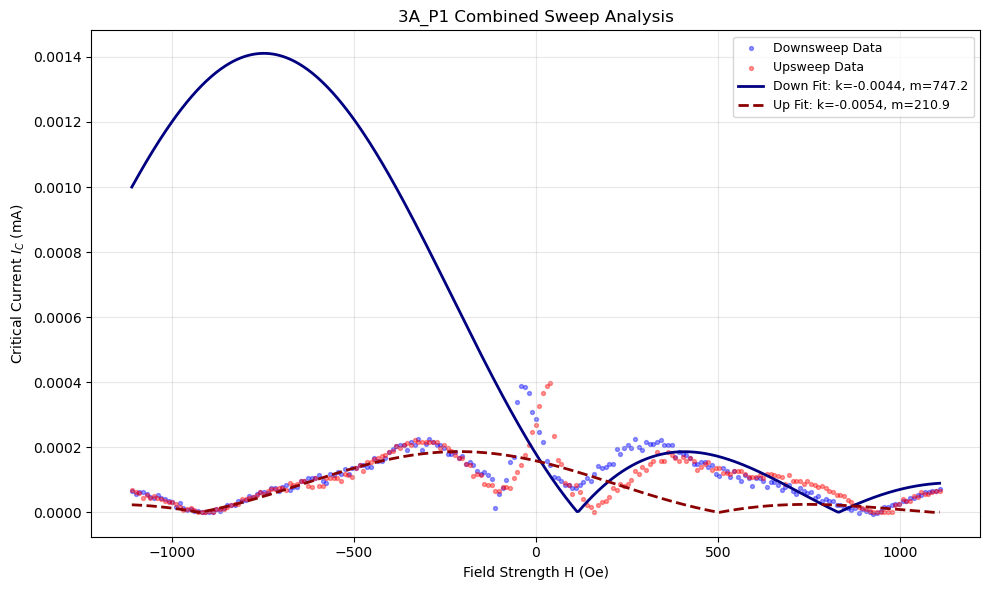

In [8]:
# ===================== Combined Plot =====================
plt.figure(figsize=(10, 6))

# Plot all data points
plt.scatter(H_down, Ic_down, s=8, color='blue', alpha=0.4, label='Downsweep Data')
plt.scatter(H_up, Ic_up, s=8, color='red', alpha=0.4, label='Upsweep Data')

# Plot full-range fits using custom parameters
H_range = np.linspace(min(H_down.min(), H_up.min()), 
                     max(H_down.max(), H_up.max()), 
                     500)

# Down sweep fit
plt.plot(H_range, 
        airy_ic(H_range, 
                custom_params['downsweep']['k'], 
                custom_params['downsweep']['m'], 
                custom_params['downsweep']['ic']),
        color='navy', lw=2, 
        label=f'Down Fit: k={custom_params["downsweep"]["k"]:.4f}, m={custom_params["downsweep"]["m"]:.1f}')

# Up sweep fit
plt.plot(H_range, 
        airy_ic(H_range, 
                custom_params['upsweep']['k'], 
                custom_params['upsweep']['m'], 
                custom_params['upsweep']['ic']),
        color='darkred', lw=2, linestyle='--',
        label=f'Up Fit: k={custom_params["upsweep"]["k"]:.4f}, m={custom_params["upsweep"]["m"]:.1f}')

plt.title(f'{sample} Combined Sweep Analysis')
plt.xlabel('Field Strength H (Oe)')
plt.ylabel('Critical Current $I_C$ (mA)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best-fit parameters from initial analysis:
Downsweep: k=-0.0044, m=747.2, ic=0.001
Upsweep: k=-0.0054, m=210.9, ic=0.000


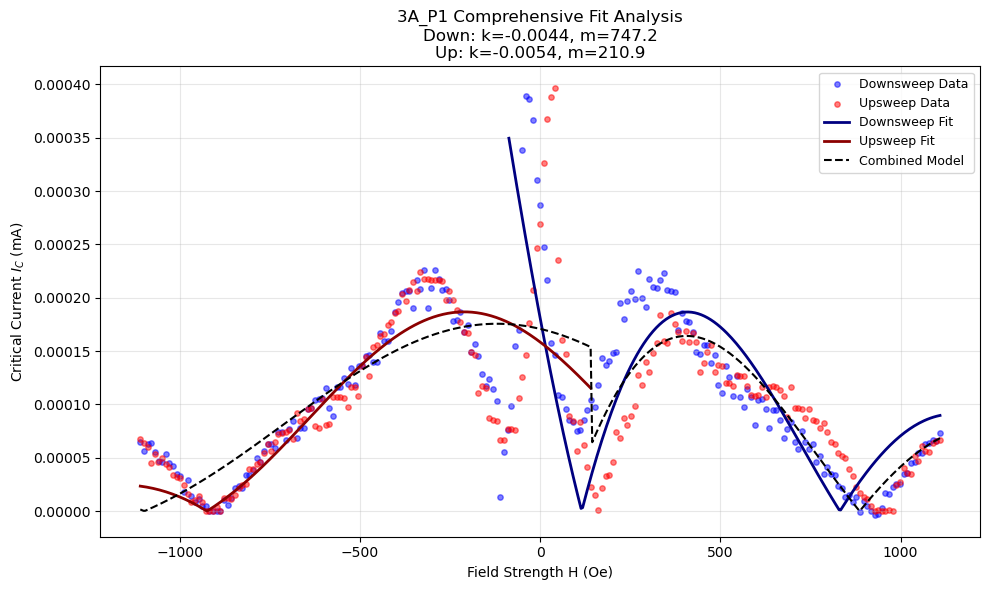

In [10]:

# Print best-fit parameters from previous analysis
print("Best-fit parameters from initial analysis:")
print(f"Downsweep: k={best_downparams[0]:.4f}, m={best_downparams[1]:.1f}, ic={best_downparams[2]:.3f}")
print(f"Upsweep: k={best_upparams[0]:.4f}, m={best_upparams[1]:.1f}, ic={best_upparams[2]:.3f}")

# ===================== Full-range Fitting =====================
def full_range_fitter(H, k, m_down, m_up, ic_down, ic_up):
    """Combined model for both sweep directions"""
    down_mask = H >= downswitch
    up_mask = H <= upswitch
    return np.piecewise(H, [down_mask, up_mask], 
                       [lambda H: airy_ic(H, k, m_down, ic_down),
                        lambda H: airy_ic(H, k, m_up, ic_up)])

# Initial guesses from previous fits
p0_combined = [best_downparams[0], 
               best_downparams[1], 
               best_upparams[1], 
               best_downparams[2], 
               best_upparams[2]]

# Combine all data
H_combined = np.concatenate([H_down, H_up])
Ic_combined = np.concatenate([Ic_down, Ic_up])

# Perform combined fit
best_combined_params, _ = optimize.curve_fit(full_range_fitter, H_combined, Ic_combined, p0=p0_combined)

# ===================== Final Visualization =====================
plt.figure(figsize=(10, 6))

# Plot raw data
plt.scatter(H_down, Ic_down, s=15, color='blue', alpha=0.5, label='Downsweep Data')
plt.scatter(H_up, Ic_up, s=15, color='red', alpha=0.5, label='Upsweep Data')

# Plot individual fits
H_fine = np.linspace(min(H_combined), max(H_combined), 500)

# Downsweep fit (H > downswitch)
mask_down = H_fine >= downswitch
plt.plot(H_fine[mask_down], 
         airy_ic(H_fine[mask_down], *best_downparams),
         color='navy', lw=2, label='Downsweep Fit')

# Upsweep fit (H < upswitch)
mask_up = H_fine <= upswitch
plt.plot(H_fine[mask_up], 
         airy_ic(H_fine[mask_up], *best_upparams),
         color='darkred', lw=2, label='Upsweep Fit')

# Combined model fit
plt.plot(H_fine, full_range_fitter(H_fine, *best_combined_params),
         'k--', lw=1.5, label='Combined Model')

plt.title(f'{sample} Comprehensive Fit Analysis\n'
         f'Down: k={best_downparams[0]:.4f}, m={best_downparams[1]:.1f}\n'
         f'Up: k={best_upparams[0]:.4f}, m={best_upparams[1]:.1f}')
plt.xlabel('Field Strength H (Oe)')
plt.ylabel('Critical Current $I_C$ (mA)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

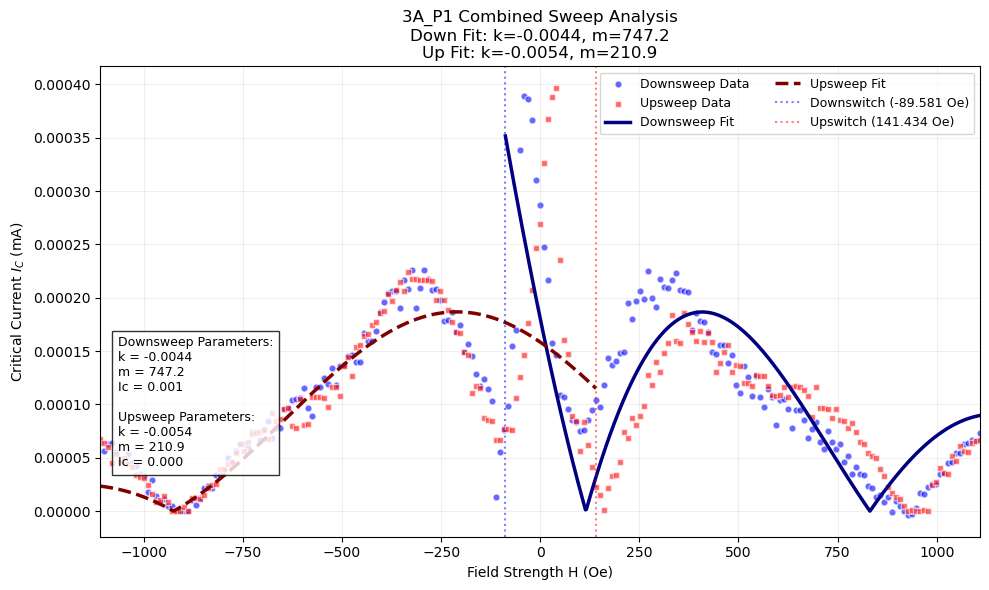

In [11]:
# ===================== Combined Plot with Switch Restrictions =====================
plt.figure(figsize=(10, 6))

# Plot raw data with different markers
plt.scatter(H_down, Ic_down, s=25, color='blue', alpha=0.6, 
           edgecolor='white', label='Downsweep Data')
plt.scatter(H_up, Ic_up, s=25, color='red', alpha=0.6, 
          marker='s', edgecolor='white', label='Upsweep Data')

# Create fine grid for plotting
H_fine = np.linspace(min(H_down.min(), H_up.min()),
                    max(H_down.max(), H_up.max()),
                    1000)

# Plot downsweep fit (only > downswitch)
down_fit_region = H_fine >= downswitch
plt.plot(H_fine[down_fit_region], 
        airy_ic(H_fine[down_fit_region], *best_downparams),
        color='navy', lw=2.5, label='Downsweep Fit')

# Plot upsweep fit (only < upswitch)
up_fit_region = H_fine <= upswitch
plt.plot(H_fine[up_fit_region], 
        airy_ic(H_fine[up_fit_region], *best_upparams),
        color='maroon', lw=2.5, linestyle='--', label='Upsweep Fit')

# Add switch point indicators
plt.axvline(downswitch, color='blue', linestyle=':', alpha=0.5, 
          label=f'Downswitch ({downswitch} Oe)')
plt.axvline(upswitch, color='red', linestyle=':', alpha=0.5,
          label=f'Upswitch ({upswitch} Oe)')

# Formatting
plt.title(f'{sample} Combined Sweep Analysis\n'
         f'Down Fit: k={best_downparams[0]:.4f}, m={best_downparams[1]:.1f}\n'
         f'Up Fit: k={best_upparams[0]:.4f}, m={best_upparams[1]:.1f}')
plt.xlabel('Field Strength H (Oe)')
plt.ylabel('Critical Current $I_C$ (mA)')
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.grid(alpha=0.2)
plt.xlim(H_fine[0], H_fine[-1])

# Add parameter table
table_text = (
    f'Downsweep Parameters:\n'
    f'k = {best_downparams[0]:.4f}\n'
    f'm = {best_downparams[1]:.1f}\n'
    f'Ic = {best_downparams[2]:.3f}\n\n'
    f'Upsweep Parameters:\n'
    f'k = {best_upparams[0]:.4f}\n'
    f'm = {best_upparams[1]:.1f}\n'
    f'Ic = {best_upparams[2]:.3f}'
)
plt.text(0.02, 0.15, table_text, transform=plt.gca().transAxes,
        fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()